In [8]:
# AI cybersecurity dataset pack
%pip install pandas numpy seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sbn

# 1. Automatically locate the uploaded CSV files

BASE_DIR = Path.cwd()

required_files = [
    "Dataset_Catalog.csv",
    "Cyber_Email_Classification.csv",
    "UCI_Phishing_Websites_327.csv",
    "UCI_Website_Phishing_375.csv"
]

print("Python working directory:", BASE_DIR)

# Search the notebook directory and its subfolders
detected_csv_files = {
    file.name.lower(): file
    for file in BASE_DIR.rglob("*.csv")
}

print("\nCSV files automatically detected:")

if detected_csv_files:
    for file_path in detected_csv_files.values():
        print("-", file_path)
else:
    print("No CSV files were detected.")

# 2. Function to load a specific required dataset

def load_dataset(file_name: str) -> pd.DataFrame:
    normalized_name = file_name.lower()

    if normalized_name not in detected_csv_files:
        available_files = [
            path.name for path in detected_csv_files.values()
        ]

        raise FileNotFoundError(
            f"\nRequired file not found: {file_name}\n"
            f"Working directory: {BASE_DIR}\n"
            f"Detected CSV files: {available_files}\n\n"
            "Upload the missing CSV file into the same directory "
            "as the notebook, and then rerun this cell."
        )

    file_path = detected_csv_files[normalized_name]

    print(f"\nLoading: {file_path}")

    try:
        return pd.read_csv(file_path)

    except UnicodeDecodeError:
        # Some Windows CSV files use a different encoding
        return pd.read_csv(file_path, encoding="latin-1")

    except pd.errors.ParserError:
        # Attempt automatic delimiter detection
        return pd.read_csv(
            file_path,
            sep=None,
            engine="python"
        )

# 3. Check whether all required files were detected

missing_files = [
    file_name
    for file_name in required_files
    if file_name.lower() not in detected_csv_files
]

if missing_files:
    print("\nMissing required files:")

    for file_name in missing_files:
        print("-", file_name)

    raise FileNotFoundError(
        "Upload the missing files shown above and rerun the cell."
    )

print("\nAll four required datasets were detected successfully.")


# 4. Load all datasets

catalog = load_dataset("Dataset_Catalog.csv")

emails = load_dataset(
    "Cyber_Email_Classification.csv"
)

primary_benchmark = load_dataset(
    "UCI_Phishing_Websites_327.csv"
)

backup_benchmark = load_dataset(
    "UCI_Website_Phishing_375.csv"
)


# 5. Display dataset information

print("\nDataset shapes:")
print("Dataset Catalog:", catalog.shape)
print("Cyber Email Classification:", emails.shape)
print("UCI Phishing Websites 327:", primary_benchmark.shape)
print("UCI Website Phishing 375:", backup_benchmark.shape)

print("\nCyber Email Classification preview:")
display(emails.head())

# 6. Automatically detect the label column

possible_label_columns = [
    "Label_name",
    "label_name",
    "Label",
    "label",
    "Category",
    "category",
    "Class",
    "class",
    "Target",
    "target"
]

label_column = next(
    (
        column
        for column in possible_label_columns
        if column in emails.columns
    ),
    None
)

if label_column:
    print(f"\nValue counts for '{label_column}':")
    print(emails[label_column].value_counts(dropna=False))
else:
    print("\nNo recognized label column was found.")
    print("Available columns:", emails.columns.tolist())

In [7]:
from pathlib import Path
import pandas as pd
import re

BASE_DIR = Path.cwd()


def normalize_filename(filename):
    """
    Makes filename matching insensitive to spaces,
    hyphens, underscores, capitalization, and (1).
    """
    filename = Path(filename).stem.lower()
    return re.sub(r"[^a-z0-9]", "", filename)


# Detect every uploaded CSV
csv_files = list(BASE_DIR.rglob("*.csv"))

detected_csv_files = {
    normalize_filename(file.name): file
    for file in csv_files
}

print("Detected CSV files:")

for file in csv_files:
    print("-", file.name)


def load_dataset(file_name, required=True):
    normalized_requested_name = normalize_filename(file_name)

    # Try an exact normalized match
    if normalized_requested_name in detected_csv_files:
        file_path = detected_csv_files[normalized_requested_name]
        print(f"Loading: {file_path.name}")
        return pd.read_csv(file_path)

    # Try matching important identifying numbers
    number_match = re.search(r"\d+", file_name)

    if number_match:
        identifying_number = number_match.group()

        possible_matches = [
            file
            for file in csv_files
            if identifying_number in file.name
        ]

        if possible_matches:
            file_path = possible_matches[0]

            print(
                f"Using closest match for {file_name}: "
                f"{file_path.name}"
            )

            return pd.read_csv(file_path)

    if required:
        raise FileNotFoundError(
            f"Required dataset was not found: {file_name}\n"
            f"Available files: {[file.name for file in csv_files]}"
        )

    print(
        f"Optional dataset not found: {file_name}. "
        "The analysis will continue without it."
    )

    return None

Detected CSV files:
- 0.01 - Titanic Data.csv
- Advertising (1).csv
- Agent_Action_Logs.csv
- Cyber_Email_Classification.csv
- Dataset_Catalog.csv
- GAN_VAE_Synthetic_Feature_Seed.csv
- Incident_Reports.csv
- Legitimate_Email.csv
- Model_Evaluation_Labels.csv
- Network_Traffic_Logs.csv
- Pakistanis_Fraud.csv
- Phishing_URL_Features.csv
- Prompt_Attack_Test_Cases.csv
- RAG_Knowledge_Base.csv
- RAG_QA_Evaluation.csv
- Security_Alerts.csv
- Threat_Intelligence_IOCs.csv
- Transformer_Text_Classification.csv
- User_Behavior_Logs.csv
- Advertising.csv
- Dataset - Twitter-training (1).csv
- Dataset - Twitter-training.csv
- Dataset - Twitter-training (2).csv
- RAG_Yis_Customer_Support_Training_Dataset.csv
- Advertisements.csv
- Advertising (1).csv
- Customer_Churn.csv
- Mall_Customers.csv
- reviews.csv
- canva_bulk_bonus_openers.csv
- canva_bulk_callout_tips.csv
- canva_bulk_chapter_openers.csv
- canva_bulk_content_pages.csv
- PhiUSIIL_Phishing_URL_Dataset.csv
- Agent_Action_Logs.csv
- Cyber_E

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sbn
import matplotlib.pyplot as plt
import re

# ==================================================
# 1. Locate all CSV files automatically
# ==================================================

BASE_DIR = Path.cwd()
csv_files = list(BASE_DIR.rglob("*.csv"))

print("Python directory:", BASE_DIR)
print("\nCSV files detected:")

for file in csv_files:
    print("-", file.name)


# ==================================================
# 2. Normalize filenames
# ==================================================

def normalize_filename(filename):
    filename = Path(filename).stem.lower()

    # Remove spaces, underscores, hyphens, and symbols
    return re.sub(r"[^a-z0-9]", "", filename)


normalized_csv_files = {
    normalize_filename(file.name): file
    for file in csv_files
}


# ==================================================
# 3. Flexible dataset-loading function
# ==================================================

def load_dataset(expected_name, identifying_terms=None):
    expected_normalized = normalize_filename(expected_name)

    # First attempt: exact normalized filename
    if expected_normalized in normalized_csv_files:
        file_path = normalized_csv_files[expected_normalized]

        print(f"Loaded: {file_path.name}")

        try:
            return pd.read_csv(file_path)

        except UnicodeDecodeError:
            return pd.read_csv(
                file_path,
                encoding="latin-1"
            )

        except pd.errors.ParserError:
            return pd.read_csv(
                file_path,
                sep=None,
                engine="python"
            )

    # Second attempt: match identifying terms
    if identifying_terms:
        identifying_terms = [
            str(term).lower()
            for term in identifying_terms
        ]

        for file in csv_files:
            normalized_actual_name = normalize_filename(file.name)

            if all(
                term in normalized_actual_name
                for term in identifying_terms
            ):
                print(
                    f"Loaded closest match: {file.name} "
                    f"for {expected_name}"
                )

                try:
                    return pd.read_csv(file)

                except UnicodeDecodeError:
                    return pd.read_csv(
                        file,
                        encoding="latin-1"
                    )

                except pd.errors.ParserError:
                    return pd.read_csv(
                        file,
                        sep=None,
                        engine="python"
                    )

    print(f"Not available: {expected_name}")
    return None


# ==================================================
# 4. Define every dataset variable
# ==================================================

catalog = load_dataset(
    "Dataset_Catalog.csv",
    identifying_terms=["dataset", "catalog"]
)

emails = load_dataset(
    "Cyber_Email_Classification.csv",
    identifying_terms=["cyber", "email"]
)

primary_benchmark = load_dataset(
    "UCI_Phishing_Websites_327.csv",
    identifying_terms=["phishing", "327"]
)

backup_benchmark = load_dataset(
    "UCI_Website_Phishing_375.csv",
    identifying_terms=["phishing", "375"]
)


# Additional descriptive variable names
dataset_catalog = catalog
cyber_email_classification = emails
uci_phishing_websites_327 = primary_benchmark
uci_website_phishing_375 = backup_benchmark


# ==================================================
# 5. Define the datasets dictionary
# ==================================================

all_datasets = {
    "Dataset Catalog": dataset_catalog,
    "Cyber Email Classification": cyber_email_classification,
    "UCI Phishing Websites 327": uci_phishing_websites_327,
    "UCI Website Phishing 375": uci_website_phishing_375
}

# Remove only datasets that were genuinely not found
datasets = {
    name: dataframe
    for name, dataframe in all_datasets.items()
    if dataframe is not None
}


# ==================================================
# 6. Confirm the results
# ==================================================

print("\n" + "=" * 60)
print("DATASET LOADING RESULTS")
print("=" * 60)

for dataset_name, dataframe in all_datasets.items():
    if dataframe is None:
        print(f"Missing/skipped: {dataset_name}")
    else:
        print(
            f"Ready: {dataset_name} — "
            f"{dataframe.shape[0]} rows × "
            f"{dataframe.shape[1]} columns"
        )

print("\nDatasets ready for EDA:", list(datasets.keys()))

if not datasets:
    raise FileNotFoundError(
        "No datasets were loaded. Upload the CSV files into "
        "the notebook directory and rerun this cell."
    )

Python directory: C:\Users\olayi

CSV files detected:
- 0.01 - Titanic Data.csv
- Advertising (1).csv
- Agent_Action_Logs.csv
- Cyber_Email_Classification.csv
- Dataset_Catalog.csv
- GAN_VAE_Synthetic_Feature_Seed.csv
- Incident_Reports.csv
- Legitimate_Email.csv
- Model_Evaluation_Labels.csv
- Network_Traffic_Logs.csv
- Pakistanis_Fraud.csv
- Phishing_URL_Features.csv
- Prompt_Attack_Test_Cases.csv
- RAG_Knowledge_Base.csv
- RAG_QA_Evaluation.csv
- Security_Alerts.csv
- Threat_Intelligence_IOCs.csv
- Transformer_Text_Classification.csv
- User_Behavior_Logs.csv
- Advertising.csv
- Dataset - Twitter-training (1).csv
- Dataset - Twitter-training.csv
- Dataset - Twitter-training (2).csv
- RAG_Yis_Customer_Support_Training_Dataset.csv
- Advertisements.csv
- Advertising (1).csv
- Customer_Churn.csv
- Mall_Customers.csv
- reviews.csv
- canva_bulk_bonus_openers.csv
- canva_bulk_callout_tips.csv
- canva_bulk_chapter_openers.csv
- canva_bulk_content_pages.csv
- PhiUSIIL_Phishing_URL_Dataset.csv

In [9]:
datasets = {
    "Dataset Catalog": catalog,
    "Cyber Email Classification": emails,
    "UCI Phishing Websites 327": primary_benchmark
}

if backup_benchmark is not None:
    datasets["UCI Website Phishing 375"] = backup_benchmark

print("\nDatasets ready for EDA:")

for name, dataframe in datasets.items():
    print(f"- {name}: {dataframe.shape}")


Datasets ready for EDA:
- Dataset Catalog: (16, 5)
- Cyber Email Classification: (6664, 11)
- UCI Phishing Websites 327: (11055, 35)


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

sbn.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


def basic_overview(dataset_name, dataframe):
    print("\n" + "=" * 70)
    print(dataset_name.upper())
    print("=" * 70)

    print("Rows:", dataframe.shape[0])
    print("Columns:", dataframe.shape[1])
    print("Duplicate rows:", dataframe.duplicated().sum())
    print("Missing values:", dataframe.isna().sum().sum())

    memory_usage = (
        dataframe.memory_usage(deep=True).sum() / 1024 ** 2
    )

    print(f"Memory usage: {memory_usage:.2f} MB")

    print("\nFirst five rows:")
    display(dataframe.head())

    print("\nColumn names:")
    print(dataframe.columns.tolist())

    print("\nData types:")
    display(
        dataframe.dtypes
        .astype(str)
        .to_frame("Data Type")
    )


for name, df in datasets.items():
    basic_overview(name, df)


DATASET CATALOG
Rows: 16
Columns: 5
Duplicate rows: 0
Missing values: 0
Memory usage: 0.00 MB

First five rows:


,file_name,purpose,primary_model_use,rows,label_column
0,Pakistanis_Fraud.csv,Synthetic phishing/fraud prototype with email ...,Email phishing classifier,3332,label
1,Legitimate_Email.csv,Synthetic legitimate email examples,Email phishing classifier,3332,label
2,Cyber_Email_Classification.csv,Combined phishing and legitimate email classif...,"Transformer, ML classifier, EDA",6664,label
3,Phishing_URL_Features.csv,URL feature dataset for malicious URL detection,URL classifier,5000,label
4,Network_Traffic_Logs.csv,Synthetic security/network event logs,"Anomaly detection, alert scoring",6000,label



Column names:
['file_name', 'purpose', 'primary_model_use', 'rows', 'label_column']

Data types:


,Data Type
file_name,object
purpose,object
primary_model_use,object
rows,int64
label_column,object



CYBER EMAIL CLASSIFICATION
Rows: 6664
Columns: 11
Duplicate rows: 0
Missing values: 1842
Memory usage: 6.36 MB

First five rows:


...

,Data Type
email_id,object
sender,object
receiver,object
date,object
subject,object
body,object
urls,object
label,int64
label_name,object
source_type,object



UCI PHISHING WEBSITES 327
Rows: 11055
Columns: 35
Duplicate rows: 5206
Missing values: 0
Memory usage: 3.60 MB

First five rows:


,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,port,https_token,request_url,url_of_anchor,links_in_tags,sfh,submitting_to_email,abnormal_url,redirect,on_mouseover,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,result,uci_target_raw,label,label_name,source_dataset_id
0,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1,-1,1,phishing_or_suspicious,327
1,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1,-1,1,phishing_or_suspicious,327
2,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1,-1,1,phishing_or_suspicious,327
3,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1,-1,1,phishing_or_suspicious,327
4,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1,1,0,legitimate_or_benign,327



Column names:
['having_ip_address', 'url_length', 'shortining_service', 'having_at_symbol', 'double_slash_redirecting', 'prefix_suffix', 'having_sub_domain', 'sslfinal_state', 'domain_registration_length', 'favicon', 'port', 'https_token', 'request_url', 'url_of_anchor', 'links_in_tags', 'sfh', 'submitting_to_email', 'abnormal_url', 'redirect', 'on_mouseover', 'rightclick', 'popupwindow', 'iframe', 'age_of_domain', 'dnsrecord', 'web_traffic', 'page_rank', 'google_index', 'links_pointing_to_page', 'statistical_report', 'result', 'uci_target_raw', 'label', 'label_name', 'source_dataset_id']

Data types:


,Data Type
having_ip_address,int64
url_length,int64
shortining_service,int64
having_at_symbol,int64
double_slash_redirecting,int64
prefix_suffix,int64
having_sub_domain,int64
sslfinal_state,int64
domain_registration_length,int64
favicon,int64


In [10]:
eda_summary = []

for name, df in datasets.items():
    numerical_columns = df.select_dtypes(
        include=np.number
    ).columns

    categorical_columns = df.select_dtypes(
        exclude=np.number
    ).columns

    eda_summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Numerical Columns": len(numerical_columns),
        "Categorical Columns": len(categorical_columns),
        "Missing Values": df.isna().sum().sum(),
        "Duplicate Rows": df.duplicated().sum(),
        "Memory MB": round(
            df.memory_usage(deep=True).sum() / 1024 ** 2,
            2
        )
    })

eda_summary = pd.DataFrame(eda_summary)

display(eda_summary)

,Dataset,Rows,Columns,Numerical Columns,Categorical Columns,Missing Values,Duplicate Rows,Memory MB
0,Dataset Catalog,16,5,1,4,0,0,0.00
1,Cyber Email Classification,6664,11,1,10,1842,0,6.36
2,UCI Phishing Websites 327,11055,35,34,1,0,5206,3.60



MISSING VALUES: DATASET CATALOG
No missing values detected.

MISSING VALUES: CYBER EMAIL CLASSIFICATION


,Missing Count,Missing Percentage
urls,1842,27.64


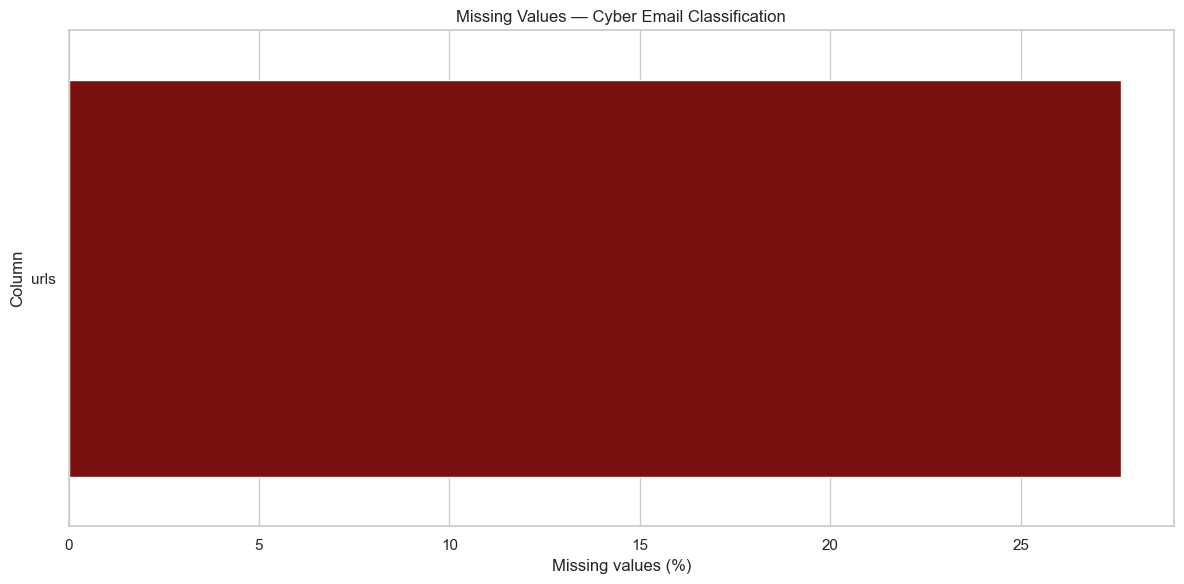


MISSING VALUES: UCI PHISHING WEBSITES 327
No missing values detected.


In [13]:
# Analyze missing values
def missing_value_analysis(dataset_name, dataframe):
    missing_table = pd.DataFrame({
        "Missing Count": dataframe.isna().sum(),
        "Missing Percentage": (
            dataframe.isna().mean() * 100
        ).round(2)
    })

    missing_table = missing_table[
        missing_table["Missing Count"] > 0
    ].sort_values(
        by="Missing Percentage",
        ascending=False
    )

    print("\n" + "=" * 70)
    print(f"MISSING VALUES: {dataset_name.upper()}")
    print("=" * 70)

    if missing_table.empty:
        print("No missing values detected.")
        return

    display(missing_table)

    plt.figure(figsize=(12, 6))

    sbn.barplot(
        data=missing_table.reset_index(),
        x="Missing Percentage",
        y="index",
        color="darkred"
    )

    plt.title(f"Missing Values — {dataset_name}")
    plt.xlabel("Missing values (%)")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()


for name, df in datasets.items():
    missing_value_analysis(name, df)

In [15]:
# Descriptive Statistcs
def descriptive_analysis(dataset_name, dataframe):
    print("\n" + "=" * 70)
    print(f"DESCRIPTIVE STATISTICS: {dataset_name.upper()}")
    print("=" * 70)

    numerical_columns = dataframe.select_dtypes(
        include=np.number
    ).columns

    categorical_columns = dataframe.select_dtypes(
        exclude=np.number
    ).columns

    if len(numerical_columns) > 0:
        print("\nNumerical statistics:")

        display(
            dataframe[numerical_columns]
            .describe()
            .T
            .round(3)
        )
    else:
        print("No numerical columns detected.")

    if len(categorical_columns) > 0:
        print("\nCategorical statistics:")

        display(
            dataframe[categorical_columns]
            .describe()
            .T
        )
    else:
        print("No categorical columns detected.")


for name, df in datasets.items():
    descriptive_analysis(name, df)


DESCRIPTIVE STATISTICS: DATASET CATALOG

Numerical statistics:


,count,mean,std,min,25%,50%,75%,max
rows,16.0,2705.5,2221.385,160.0,787.5,2416.0,4625.0,6664.0



Categorical statistics:


,count,unique,top,freq
file_name,16,16,Pakistanis_Fraud.csv,1
purpose,16,16,Synthetic phishing/fraud prototype with email ...,1
primary_model_use,16,15,Email phishing classifier,2
label_column,16,7,label,9



DESCRIPTIVE STATISTICS: CYBER EMAIL CLASSIFICATION

Numerical statistics:


...

,count,unique,top,freq
email_id,6664,6664,LEGIT-02932,1
sender,6664,6650,fatima.hussain993@school-notices.invalid,2
receiver,6664,4535,contact@university.example,38
date,6664,6650,2026-05-09 15:11:00,2
subject,6664,25,Monthly Payroll Notice,351
body,6664,3336,This is a normal internal communication about ...,687
urls,4822,33,1,1795
label_name,6664,2,legitimate,3332
source_type,6664,1,synthetic_kaggle_prototype,6664
split,6664,3,train,4653



DESCRIPTIVE STATISTICS: UCI PHISHING WEBSITES 327

Numerical statistics:


,count,mean,std,min,25%,50%,75%,max
having_ip_address,11055.0,0.314,0.950,-1.0,-1.0,1.0,1.0,1.0
url_length,11055.0,-0.633,0.766,-1.0,-1.0,-1.0,-1.0,1.0
shortining_service,11055.0,0.739,0.674,-1.0,1.0,1.0,1.0,1.0
having_at_symbol,11055.0,0.701,0.714,-1.0,1.0,1.0,1.0,1.0
double_slash_redirecting,11055.0,0.741,0.671,-1.0,1.0,1.0,1.0,1.0
prefix_suffix,11055.0,-0.735,0.678,-1.0,-1.0,-1.0,-1.0,1.0
having_sub_domain,11055.0,0.064,0.818,-1.0,-1.0,0.0,1.0,1.0
sslfinal_state,11055.0,0.251,0.912,-1.0,-1.0,1.0,1.0,1.0
domain_registration_length,11055.0,-0.337,0.942,-1.0,-1.0,-1.0,1.0,1.0
favicon,11055.0,0.629,0.778,-1.0,1.0,1.0,1.0,1.0



Categorical statistics:


,count,unique,top,freq
label_name,11055,2,legitimate_or_benign,6157


In [17]:
# Detection of Possible Target Columns

possible_target_names = [
    "label_name",
    "label",
    "class",
    "category",
    "target",
    "result",
    "status",
    "type"
]


def detect_target_column(dataframe):
    column_lookup = {
        str(column).strip().lower(): column
        for column in dataframe.columns
    }

    for target_name in possible_target_names:
        if target_name in column_lookup:
            return column_lookup[target_name]

    return None


for name, df in datasets.items():
    target_column = detect_target_column(df)

    print("\nDataset:", name)

    if target_column is None:
        print("Target column not automatically detected.")
        print("Available columns:", df.columns.tolist())
    else:
        print("Detected target column:", target_column)

        target_summary = pd.DataFrame({
            "Count": df[target_column].value_counts(
                dropna=False
            ),
            "Percentage": (
                df[target_column]
                .value_counts(
                    normalize=True,
                    dropna=False
                )
                .mul(100)
                .round(2)
            )
        })

        display(target_summary)


Dataset: Dataset Catalog
Target column not automatically detected.
Available columns: ['file_name', 'purpose', 'primary_model_use', 'rows', 'label_column']

Dataset: Cyber Email Classification
Detected target column: label_name


,Count,Percentage
label_name,,
legitimate,3332,50.0
phishing,3332,50.0



Dataset: UCI Phishing Websites 327
Detected target column: label_name


,Count,Percentage
label_name,,
legitimate_or_benign,6157,55.69
phishing_or_suspicious,4898,44.31


Target plot skipped for Dataset Catalog: no target column was detected.


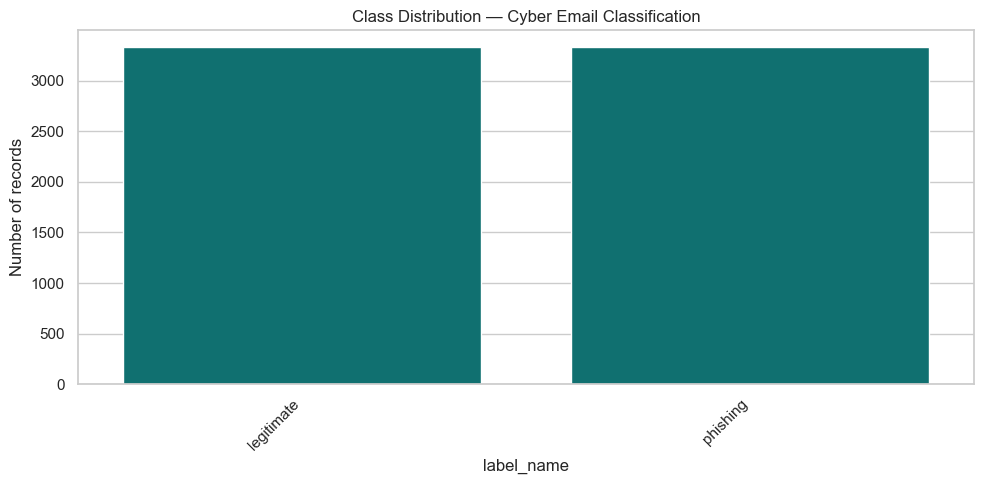

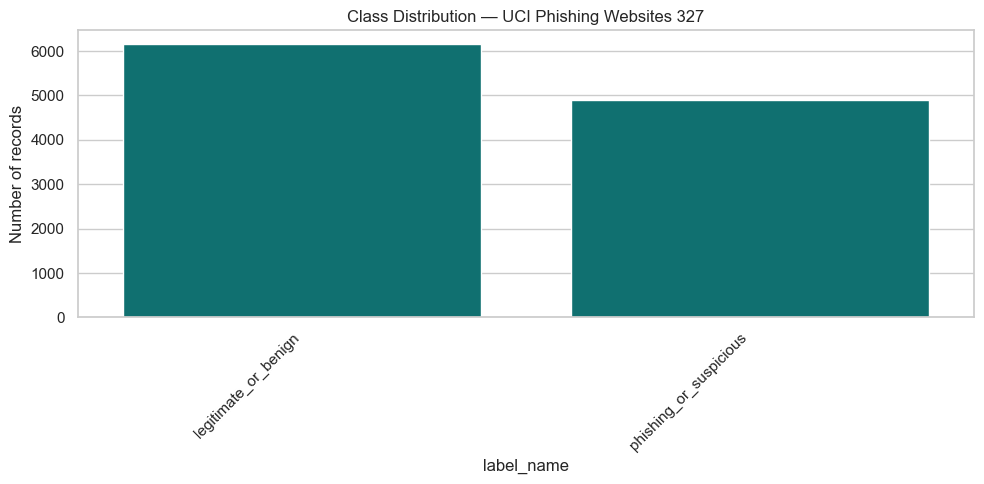

In [19]:
# Target Dsitribution Ploting

def plot_target_distribution(dataset_name, dataframe):
    target_column = detect_target_column(dataframe)

    if target_column is None:
        print(
            f"Target plot skipped for {dataset_name}: "
            "no target column was detected."
        )
        return

    target_counts = dataframe[
        target_column
    ].value_counts(dropna=False)

    # Avoid unreadable plots
    if len(target_counts) > 30:
        print(
            f"Target plot skipped for {dataset_name}: "
            f"{target_column} has {len(target_counts)} categories."
        )
        return

    plt.figure(figsize=(10, 5))

    sbn.countplot(
        data=dataframe,
        x=target_column,
        order=target_counts.index,
        color="teal"
    )

    plt.title(f"Class Distribution — {dataset_name}")
    plt.xlabel(target_column)
    plt.ylabel("Number of records")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


for name, df in datasets.items():
    plot_target_distribution(name, df)

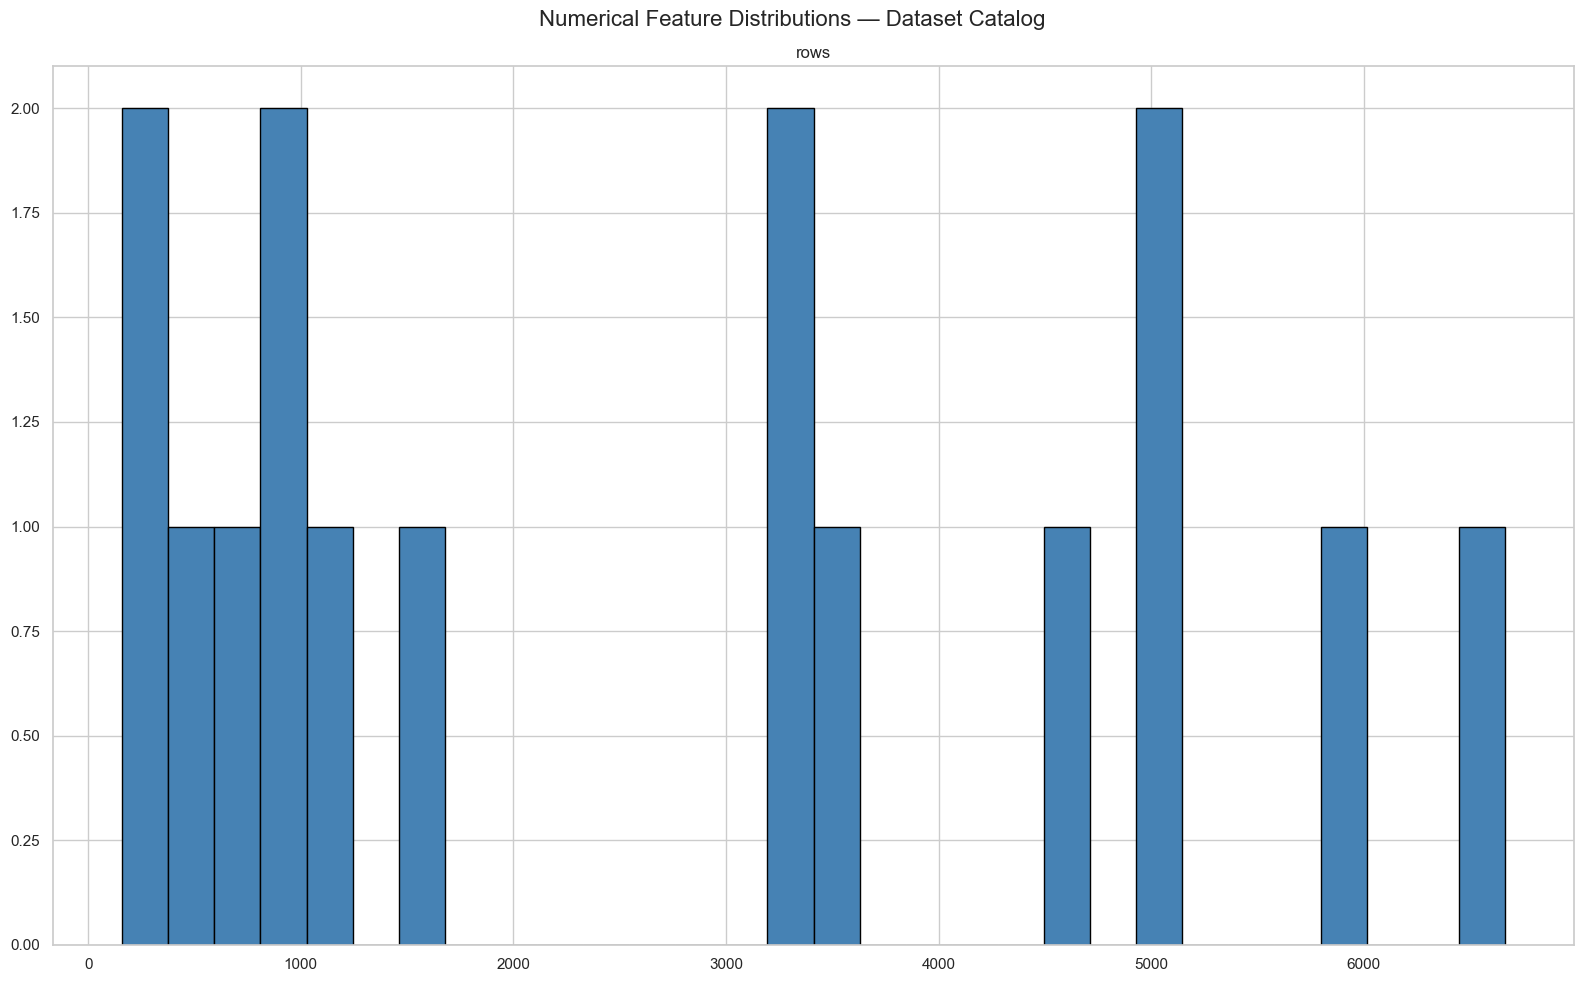

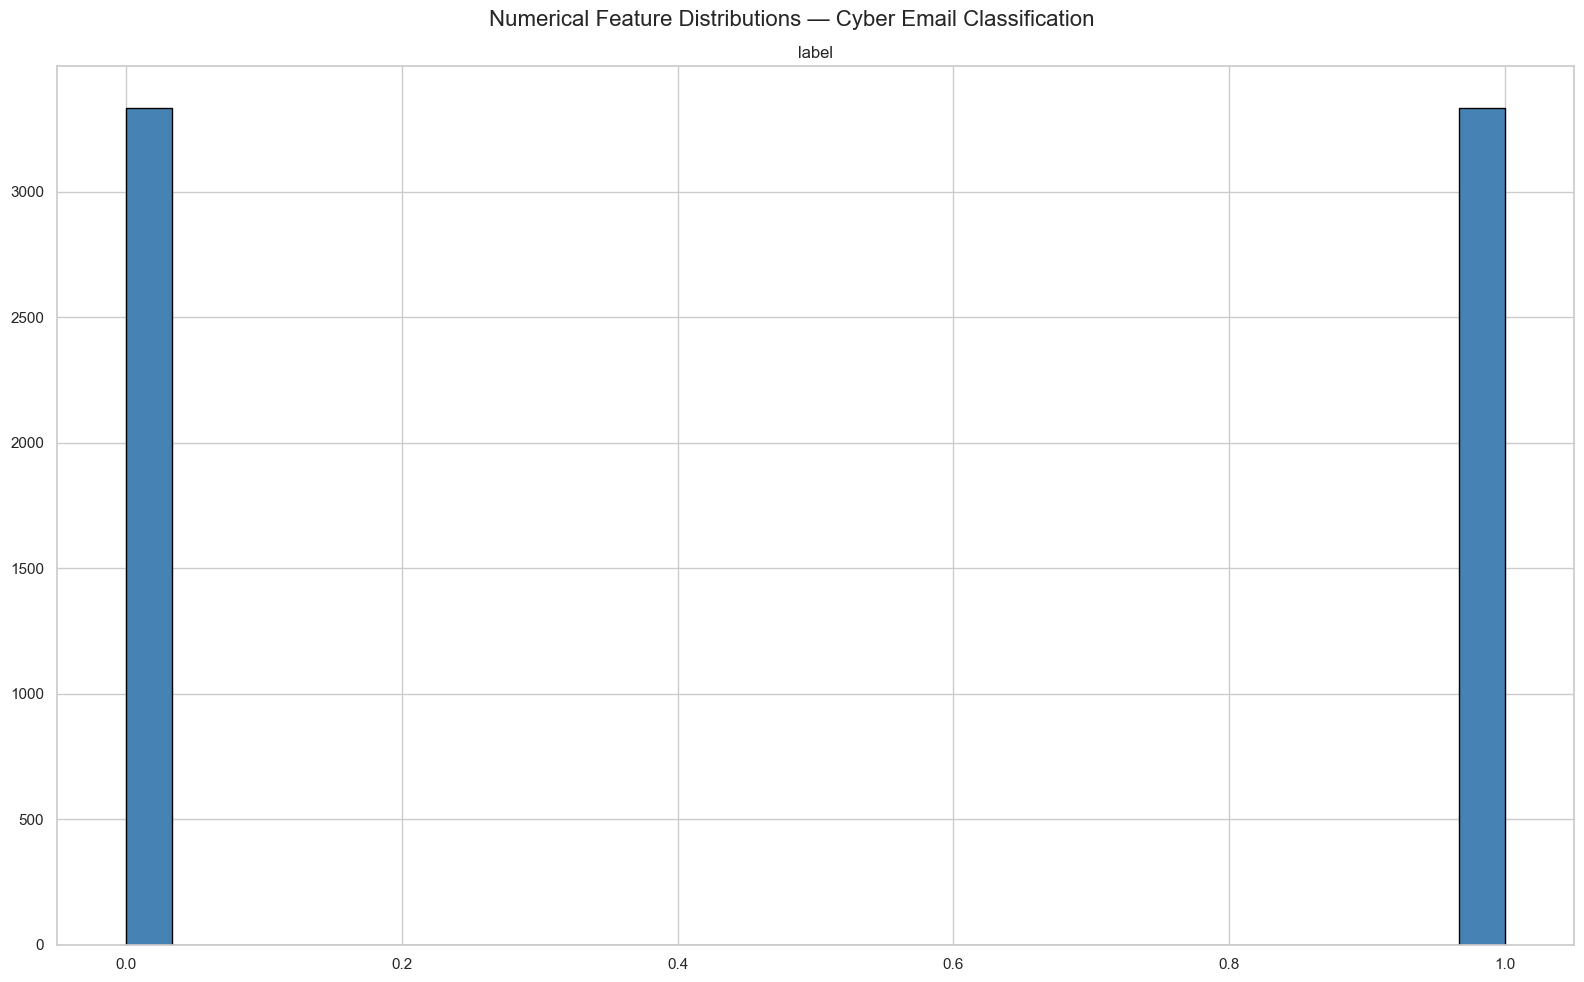

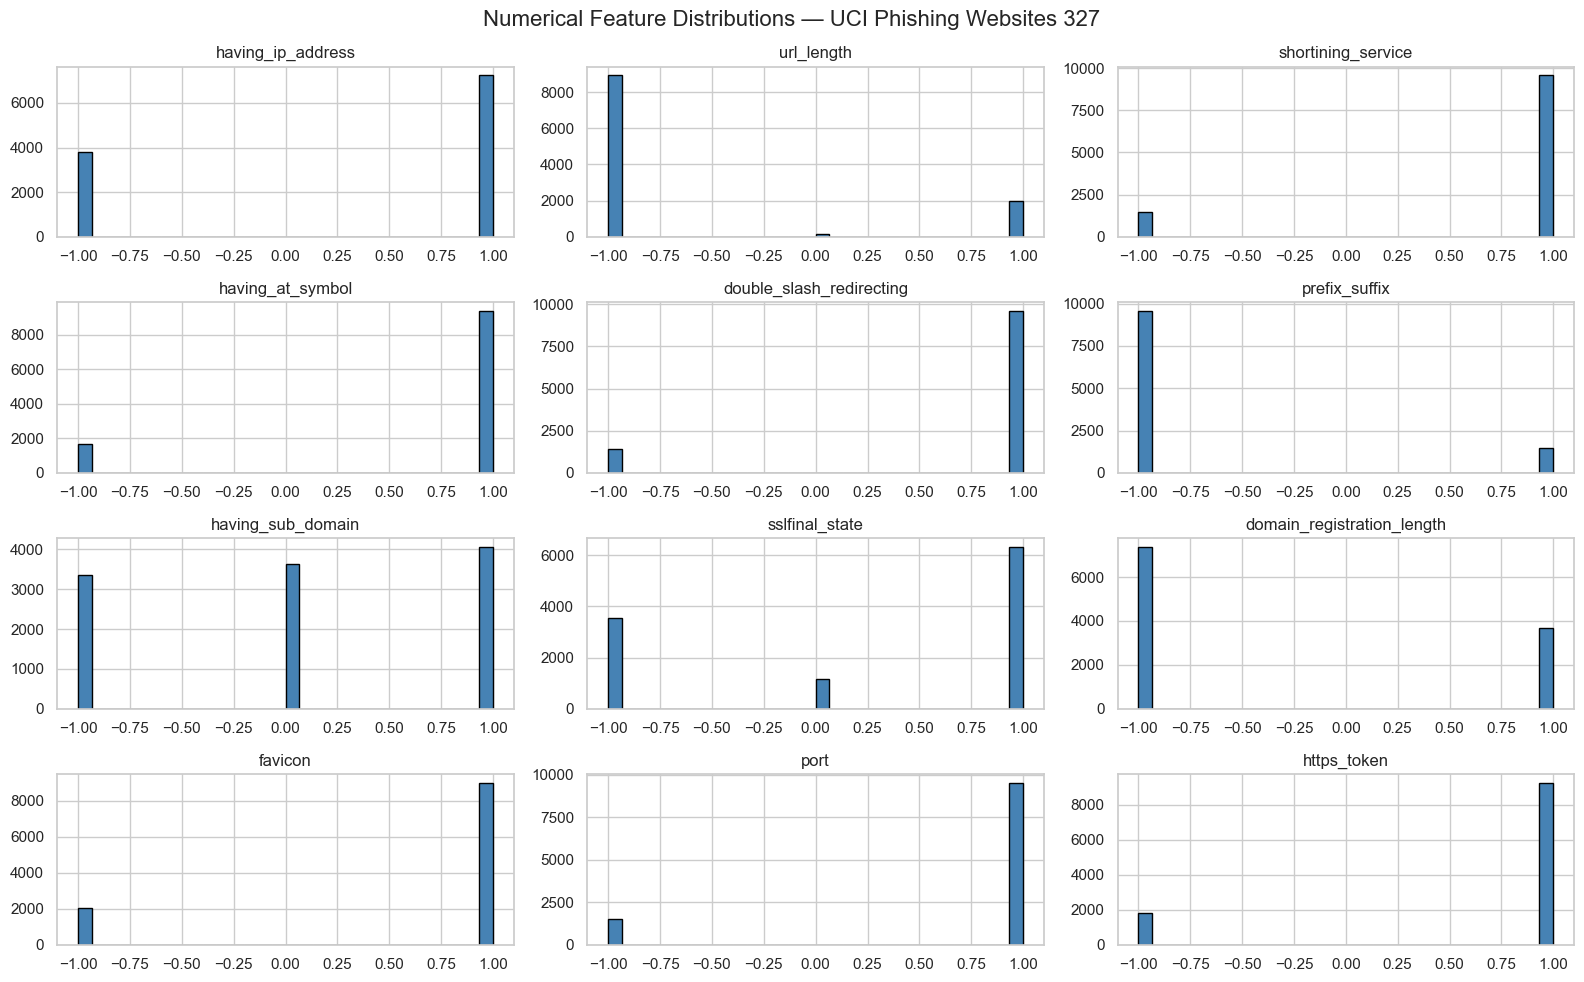

In [20]:
# Numerical Districbution

def plot_numerical_distributions(
    dataset_name,
    dataframe,
    maximum_columns=12
):
    numerical_columns = dataframe.select_dtypes(
        include=np.number
    ).columns.tolist()

    if not numerical_columns:
        print(
            f"No numerical columns detected in {dataset_name}."
        )
        return

    selected_columns = numerical_columns[:maximum_columns]

    dataframe[selected_columns].hist(
        figsize=(16, 10),
        bins=30,
        color="steelblue",
        edgecolor="black"
    )

    plt.suptitle(
        f"Numerical Feature Distributions — {dataset_name}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


for name, df in datasets.items():
    plot_numerical_distributions(name, df)

Correlation heatmap skipped for Dataset Catalog: not enough numerical columns.
Correlation heatmap skipped for Cyber Email Classification: not enough numerical columns.


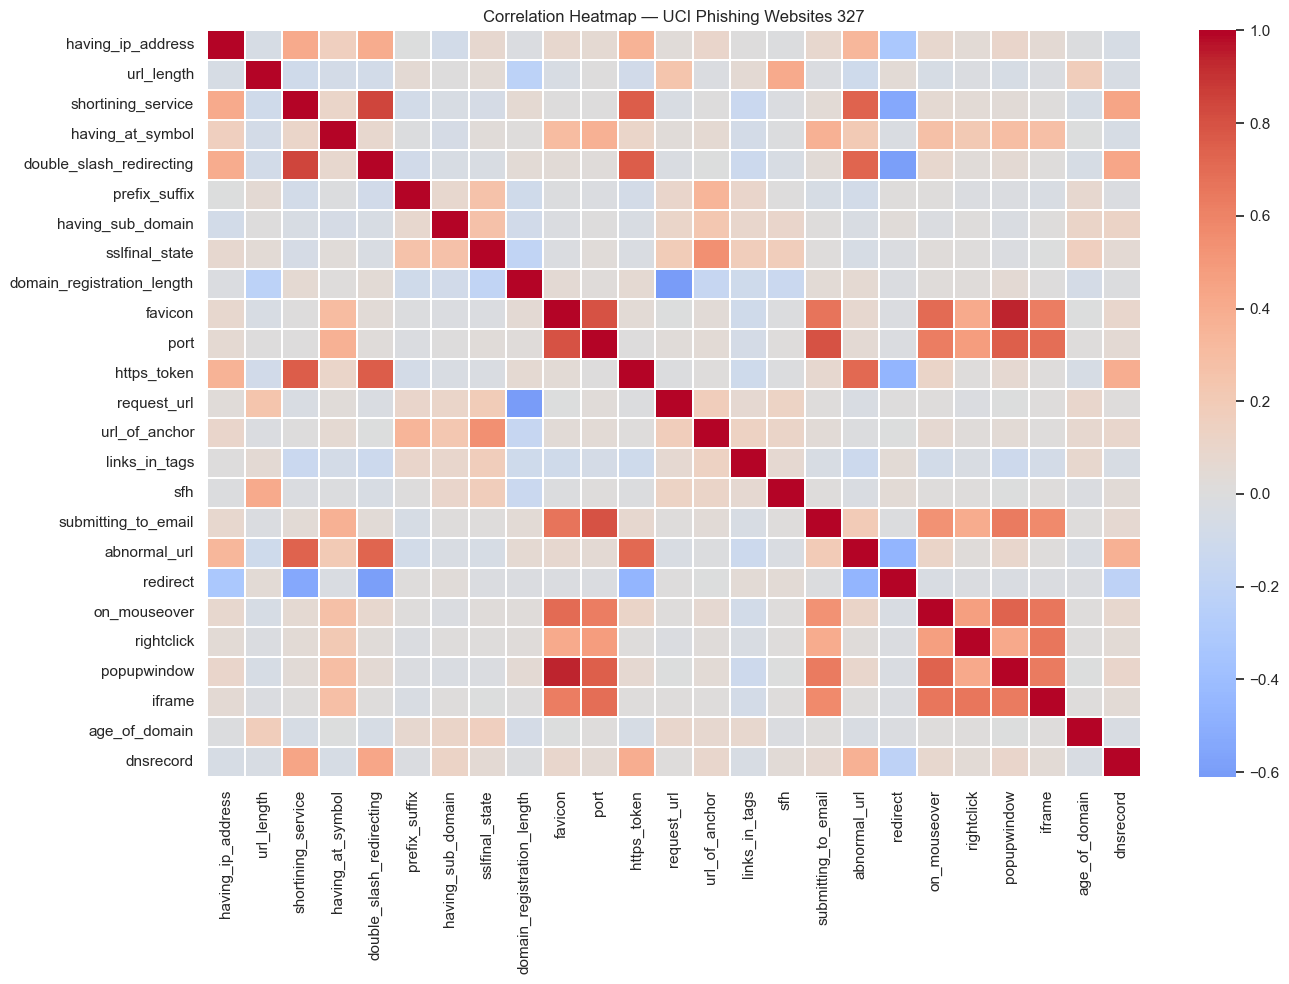

In [21]:
# Plot Correctlation Heatmap

def plot_correlation_heatmap(
    dataset_name,
    dataframe,
    maximum_columns=25
):
    numerical_data = dataframe.select_dtypes(
        include=np.number
    )

    # Remove columns with only one unique value
    numerical_data = numerical_data.loc[
        :,
        numerical_data.nunique(dropna=False) > 1
    ]

    if numerical_data.shape[1] < 2:
        print(
            f"Correlation heatmap skipped for {dataset_name}: "
            "not enough numerical columns."
        )
        return

    numerical_data = numerical_data.iloc[
        :,
        :maximum_columns
    ]

    correlation_matrix = numerical_data.corr()

    plt.figure(figsize=(14, 10))

    sbn.heatmap(
        correlation_matrix,
        cmap="coolwarm",
        center=0,
        annot=correlation_matrix.shape[1] <= 12,
        fmt=".2f",
        linewidths=0.25
    )

    plt.title(f"Correlation Heatmap — {dataset_name}")
    plt.tight_layout()
    plt.show()


for name, df in datasets.items():
    plot_correlation_heatmap(name, df)

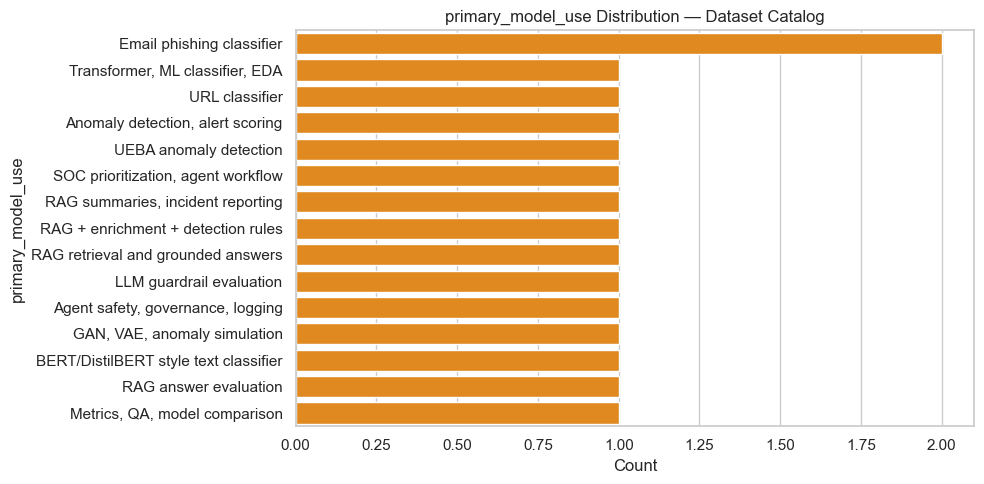

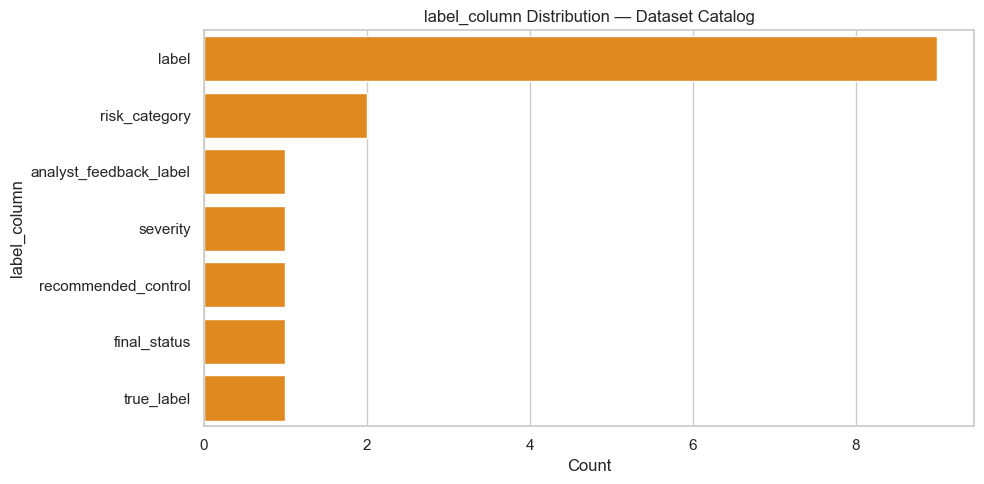

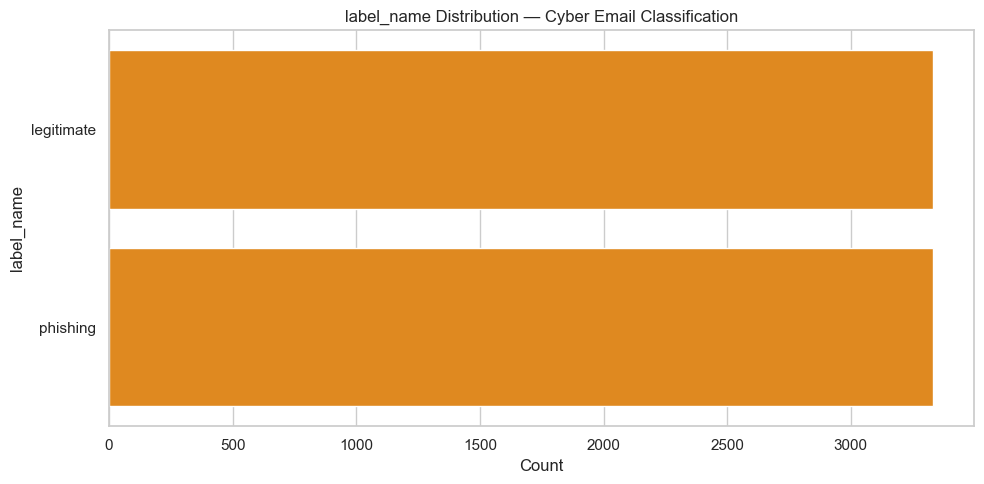

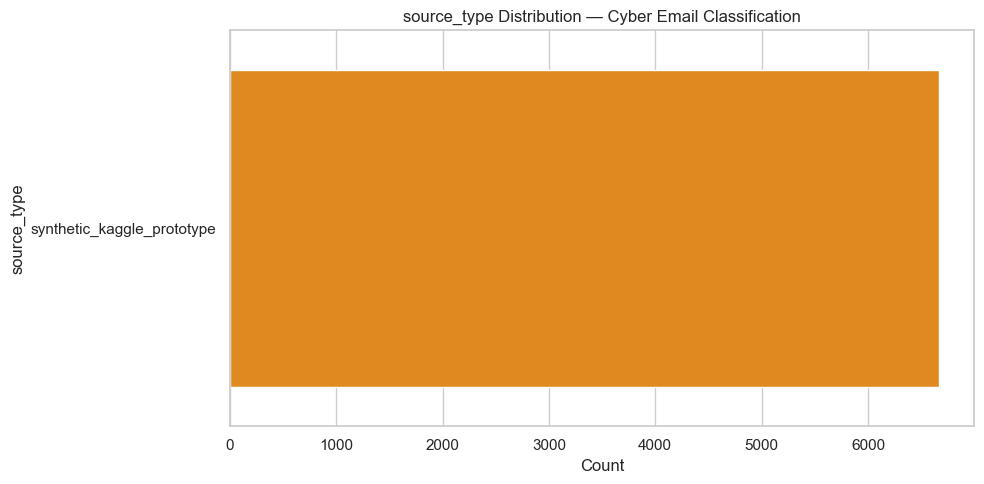

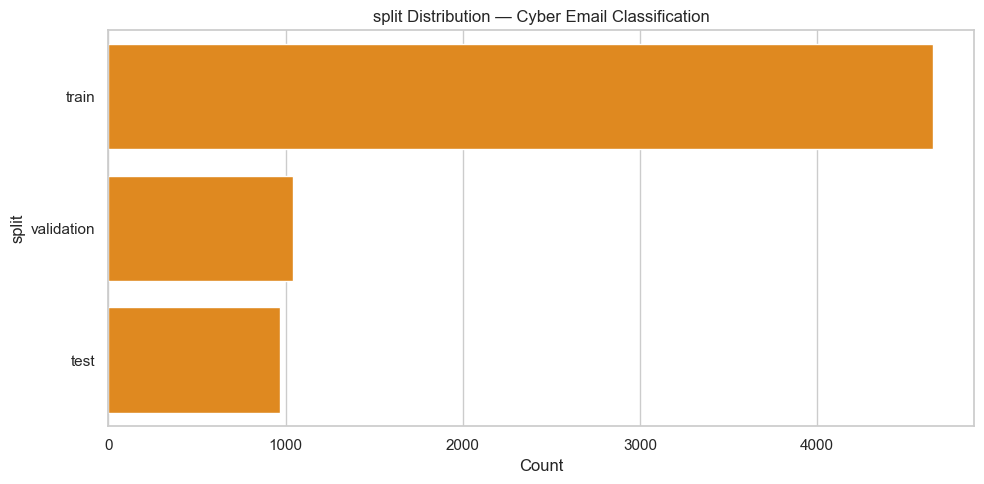

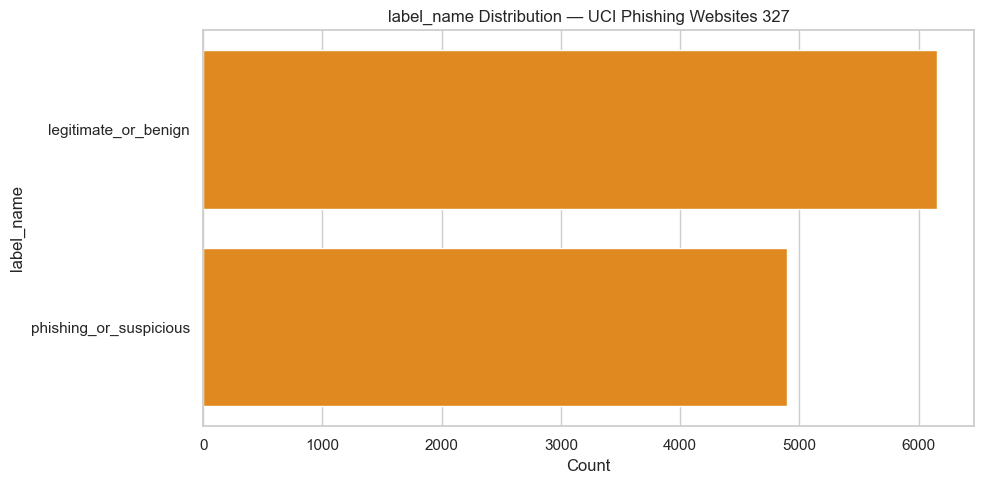

In [22]:
# Analyse Categorical Features

def plot_categorical_features(
    dataset_name,
    dataframe,
    maximum_columns=8,
    maximum_categories=15
):
    categorical_columns = dataframe.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    number_plotted = 0

    for column in categorical_columns:
        unique_values = dataframe[column].nunique(
            dropna=False
        )

        # Avoid plotting email text or ID-like columns
        if unique_values > maximum_categories:
            continue

        plt.figure(figsize=(10, 5))

        order = (
            dataframe[column]
            .value_counts(dropna=False)
            .index
        )

        sbn.countplot(
            data=dataframe,
            y=column,
            order=order,
            color="darkorange"
        )

        plt.title(
            f"{column} Distribution — {dataset_name}"
        )

        plt.xlabel("Count")
        plt.ylabel(column)
        plt.tight_layout()
        plt.show()

        number_plotted += 1

        if number_plotted >= maximum_columns:
            break

    if number_plotted == 0:
        print(
            f"No suitable categorical columns to plot "
            f"in {dataset_name}."
        )


for name, df in datasets.items():
    plot_categorical_features(name, df)

In [24]:
# Detect potential outliers

def outlier_analysis(dataset_name, dataframe):
    numerical_columns = dataframe.select_dtypes(
        include=np.number
    ).columns

    results = []

    for column in numerical_columns:
        values = dataframe[column].dropna()

        # Skip binary or low-cardinality cybersecurity features
        if values.nunique() < 5:
            continue

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        if iqr == 0:
            continue

        lower_boundary = q1 - (1.5 * iqr)
        upper_boundary = q3 + (1.5 * iqr)

        outlier_count = (
            (values < lower_boundary) |
            (values > upper_boundary)
        ).sum()

        results.append({
            "Feature": column,
            "Outlier Count": outlier_count,
            "Outlier Percentage": round(
                outlier_count / len(values) * 100,
                2
            ),
            "Lower Boundary": round(lower_boundary, 3),
            "Upper Boundary": round(upper_boundary, 3)
        })

    print("\n" + "=" * 70)
    print(f"OUTLIER ANALYSIS: {dataset_name.upper()}")
    print("=" * 70)

    if results:
        results_df = pd.DataFrame(results).sort_values(
            "Outlier Percentage",
            ascending=False
        )

        display(results_df)
    else:
        print("No applicable numerical features found.")


for name, df in datasets.items():
    outlier_analysis(name, df)


OUTLIER ANALYSIS: DATASET CATALOG


,Feature,Outlier Count,Outlier Percentage,Lower Boundary,Upper Boundary
0,rows,0,0.0,-4968.75,10381.25



OUTLIER ANALYSIS: CYBER EMAIL CLASSIFICATION
No applicable numerical features found.

OUTLIER ANALYSIS: UCI PHISHING WEBSITES 327
No applicable numerical features found.


In [1]:
%pip install -U scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

sbn.set_theme(style="whitegrid")

RANDOM_STATE = 42
MODEL_DIR = Path.cwd() / "trained_models"
MODEL_DIR.mkdir(exist_ok=True)

print("Model output directory:", MODEL_DIR)

Model output directory: C:\Users\olayi\trained_models


In [28]:
from pathlib import Path
import pandas as pd
import re

BASE_DIR = Path.cwd()


def normalize_filename(filename):
    return re.sub(
        r"[^a-z0-9]",
        "",
        Path(filename).stem.lower()
    )


# Detect all CSV files
csv_files = list(BASE_DIR.rglob("*.csv"))

print("CSV files detected:")

for file in csv_files:
    print("-", file.name)


def find_and_load(search_terms):
    for file in csv_files:
        normalized_name = normalize_filename(file.name)

        if all(
            normalize_filename(term) in normalized_name
            for term in search_terms
        ):
            print("Loaded:", file.name)

            try:
                return pd.read_csv(file)

            except UnicodeDecodeError:
                return pd.read_csv(
                    file,
                    encoding="latin-1"
                )

            except pd.errors.ParserError:
                return pd.read_csv(
                    file,
                    sep=None,
                    engine="python"
                )

    print("Not found:", search_terms)
    return None


# Define every dataset variable again
catalog = find_and_load(["dataset", "catalog"])

emails = find_and_load(["cyber", "email"])

primary_benchmark = find_and_load([
    "phishing",
    "327"
])

backup_benchmark = find_and_load([
    "phishing",
    "375"
])


# Create a dictionary containing only available datasets
all_datasets = {
    "Dataset Catalog": catalog,
    "Cyber Email Classification": emails,
    "UCI Phishing Websites 327": primary_benchmark,
    "UCI Website Phishing 375": backup_benchmark
}

datasets = {
    name: dataframe
    for name, dataframe in all_datasets.items()
    if dataframe is not None
}


print("\nDatasets successfully defined:")

for name, dataframe in datasets.items():
    print(
        f"- {name}: "
        f"{dataframe.shape[0]} rows × "
        f"{dataframe.shape[1]} columns"
    )

if not datasets:
    raise FileNotFoundError(
        "No datasets were found in the notebook directory."
    )

CSV files detected:
- 0.01 - Titanic Data.csv
- Advertising (1).csv
- Agent_Action_Logs.csv
- Cyber_Email_Classification.csv
- Dataset_Catalog.csv
- GAN_VAE_Synthetic_Feature_Seed.csv
- Incident_Reports.csv
- Legitimate_Email.csv
- Model_Evaluation_Labels.csv
- Network_Traffic_Logs.csv
- Pakistanis_Fraud.csv
- Phishing_URL_Features.csv
- Prompt_Attack_Test_Cases.csv
- RAG_Knowledge_Base.csv
- RAG_QA_Evaluation.csv
- Security_Alerts.csv
- Threat_Intelligence_IOCs.csv
- Transformer_Text_Classification.csv
- User_Behavior_Logs.csv
- Advertising.csv
- Dataset - Twitter-training (1).csv
- Dataset - Twitter-training.csv
- Dataset - Twitter-training (2).csv
- RAG_Yis_Customer_Support_Training_Dataset.csv
- Advertisements.csv
- Advertising (1).csv
- Customer_Churn.csv
- Mall_Customers.csv
- model_performance_results.csv
- reviews.csv
- canva_bulk_bonus_openers.csv
- canva_bulk_callout_tips.csv
- canva_bulk_chapter_openers.csv
- canva_bulk_content_pages.csv
- PhiUSIIL_Phishing_URL_Dataset.csv
-

In [29]:
print(type(datasets))
print(datasets.keys())

<class 'dict'>
dict_keys(['Dataset Catalog', 'Cyber Email Classification', 'UCI Phishing Websites 327'])


In [31]:
import numpy as np


def clean_dataset(dataframe, dataset_name):
    cleaned = dataframe.copy()

    original_shape = cleaned.shape

    cleaned.columns = [
        re.sub(
            r"[^a-zA-Z0-9_]+",
            "_",
            str(column).strip()
        ).strip("_")
        for column in cleaned.columns
    ]

    missing_markers = [
        "",
        " ",
        "?",
        "NA",
        "N/A",
        "na",
        "null",
        "NULL",
        "None"
    ]

    cleaned = cleaned.replace(missing_markers, np.nan)
    cleaned = cleaned.dropna(axis=0, how="all")
    cleaned = cleaned.dropna(axis=1, how="all")

    duplicate_count = cleaned.duplicated().sum()

    cleaned = (
        cleaned
        .drop_duplicates()
        .reset_index(drop=True)
    )

    print("\n", dataset_name)
    print("Original shape:", original_shape)
    print("Duplicates removed:", duplicate_count)
    print("Cleaned shape:", cleaned.shape)

    return cleaned


cleaned_datasets = {
    name: clean_dataset(dataframe, name)
    for name, dataframe in datasets.items()
}


catalog_clean = cleaned_datasets.get(
    "Dataset Catalog"
)

emails_clean = cleaned_datasets.get(
    "Cyber Email Classification"
)

primary_clean = cleaned_datasets.get(
    "UCI Phishing Websites 327"
)

backup_clean = cleaned_datasets.get(
    "UCI Website Phishing 375"
)

print("\nCleaning completed successfully.")


 Dataset Catalog
Original shape: (16, 5)
Duplicates removed: 0
Cleaned shape: (16, 5)

 Cyber Email Classification
Original shape: (6664, 11)
Duplicates removed: 0
Cleaned shape: (6664, 11)

 UCI Phishing Websites 327
Original shape: (11055, 35)
Duplicates removed: 5206
Cleaned shape: (5849, 35)

Cleaning completed successfully.


In [30]:
def clean_dataset(dataframe, dataset_name):
    cleaned = dataframe.copy()

    original_rows, original_columns = cleaned.shape

    # Clean column names
    cleaned.columns = [
        re.sub(
            r"[^a-zA-Z0-9_]+",
            "_",
            str(column).strip()
        ).strip("_")
        for column in cleaned.columns
    ]

    # Replace common missing-value markers
    missing_markers = [
        "",
        " ",
        "?",
        "NA",
        "N/A",
        "na",
        "null",
        "NULL",
        "None",
        "unknown"
    ]

    cleaned = cleaned.replace(missing_markers, np.nan)

    # Remove completely empty rows and columns
    cleaned = cleaned.dropna(axis=0, how="all")
    cleaned = cleaned.dropna(axis=1, how="all")

    # Remove exact duplicates
    duplicate_count = cleaned.duplicated().sum()
    cleaned = cleaned.drop_duplicates().reset_index(drop=True)

    print("\n" + "=" * 65)
    print(dataset_name.upper())
    print("=" * 65)
    print("Original shape:", (original_rows, original_columns))
    print("Duplicates removed:", duplicate_count)
    print("Cleaned shape:", cleaned.shape)
    print("Remaining missing values:", cleaned.isna().sum().sum())

    return cleaned


cleaned_datasets = {}

for dataset_name, dataframe in datasets.items():
    cleaned_datasets[dataset_name] = clean_dataset(
        dataframe,
        dataset_name
    )


DATASET CATALOG
Original shape: (16, 5)
Duplicates removed: 0
Cleaned shape: (16, 5)
Remaining missing values: 0

CYBER EMAIL CLASSIFICATION
Original shape: (6664, 11)
Duplicates removed: 0
Cleaned shape: (6664, 11)
Remaining missing values: 1842

UCI PHISHING WEBSITES 327
Original shape: (11055, 35)
Duplicates removed: 5206
Cleaned shape: (5849, 35)
Remaining missing values: 0


In [32]:
TARGET_NAMES = [
    "label_name",
    "label",
    "class",
    "category",
    "target",
    "result",
    "status",
    "type",
    "output",
    "phishing",
    "is_phishing"
]


def detect_target_column(dataframe):
    if dataframe is None:
        return None

    lookup = {
        str(column).strip().lower(): column
        for column in dataframe.columns
    }

    for possible_target in TARGET_NAMES:
        if possible_target in lookup:
            return lookup[possible_target]

    for column in dataframe.columns:
        normalized_column = str(column).lower()

        if any(
            target_name in normalized_column
            for target_name in TARGET_NAMES
        ):
            unique_values = dataframe[column].nunique(
                dropna=True
            )

            if 2 <= unique_values <= 30:
                return column

    # UCI datasets commonly place the target last
    last_column = dataframe.columns[-1]

    if 2 <= dataframe[last_column].nunique(dropna=True) <= 30:
        return last_column

    return None


modeling_datasets = {
    "Cyber Email Classification": emails_clean,
    "UCI Phishing Websites 327": primary_clean,
    "UCI Website Phishing 375": backup_clean
}

target_columns = {}

for name, dataframe in modeling_datasets.items():
    if dataframe is None:
        continue

    target = detect_target_column(dataframe)
    target_columns[name] = target

    print("\nDataset:", name)
    print("Detected target:", target)

    if target is not None:
        print(dataframe[target].value_counts(dropna=False))
    else:
        print("Columns:", dataframe.columns.tolist())


Dataset: Cyber Email Classification
Detected target: label_name
label_name
legitimate    3332
phishing      3332
Name: count, dtype: int64

Dataset: UCI Phishing Websites 327
Detected target: label_name
label_name
phishing_or_suspicious    3019
legitimate_or_benign      2830
Name: count, dtype: int64


In [34]:
catalog_clean = cleaned_datasets.get("Dataset Catalog")

emails_clean = cleaned_datasets.get(
    "Cyber Email Classification"
)

primary_clean = cleaned_datasets.get(
    "UCI Phishing Websites 327"
)

backup_clean = cleaned_datasets.get(
    "UCI Website Phishing 375"
)

print("Cleaned datasets are ready.")

Cleaned datasets are ready.


In [35]:
#5 Detect email text columns

def detect_text_columns(dataframe, target_column=None):
    text_columns = []

    preferred_words = [
        "text",
        "email",
        "message",
        "body",
        "subject",
        "content",
        "description"
    ]

    for column in dataframe.columns:
        if column == target_column:
            continue

        if dataframe[column].dtype != "object":
            continue

        normalized_name = str(column).lower()

        sample = dataframe[column].dropna().astype(str).head(500)

        average_length = (
            sample.str.len().mean()
            if len(sample) > 0 else 0
        )

        if (
            any(word in normalized_name for word in preferred_words)
            or average_length >= 30
        ):
            text_columns.append(column)

    return text_columns


if emails_clean is not None:
    email_target = target_columns.get(
        "Cyber Email Classification"
    )

    email_text_columns = detect_text_columns(
        emails_clean,
        email_target
    )

    print("Detected email text columns:", email_text_columns)

Detected email text columns: ['email_id', 'sender', 'subject', 'body']


Text columns used: ['email_id', 'sender', 'subject', 'body']
Training records: 6664
Classes: ['legitimate', 'phishing']

EMAIL LOGISTIC REGRESSION
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00       667
    phishing       1.00      1.00      1.00       666

    accuracy                           1.00      1333
   macro avg       1.00      1.00      1.00      1333
weighted avg       1.00      1.00      1.00      1333



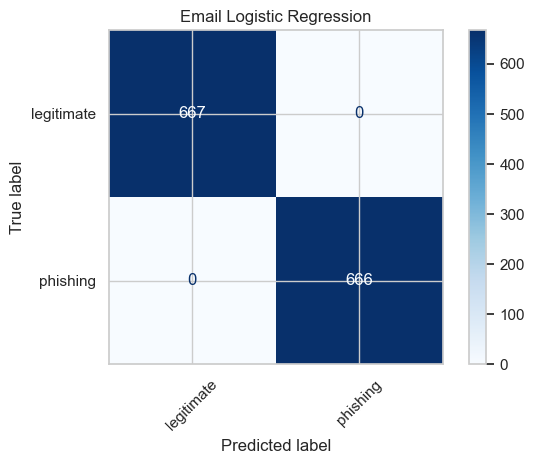


EMAIL SGD CLASSIFIER
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00       667
    phishing       1.00      1.00      1.00       666

    accuracy                           1.00      1333
   macro avg       1.00      1.00      1.00      1333
weighted avg       1.00      1.00      1.00      1333



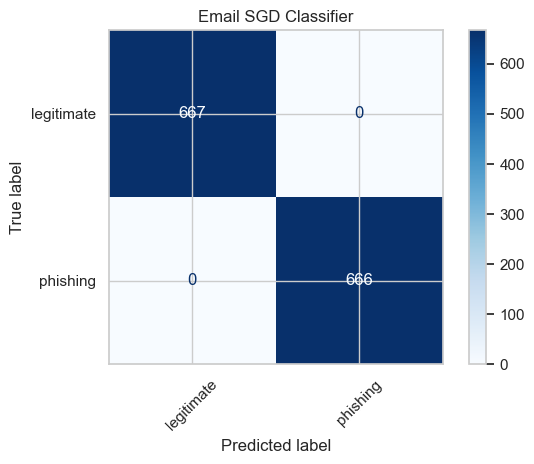

In [36]:
# 6. Train the email-classification models to combines relevant email text columns, applies TF-IDF, and compares Logistic Regression 
# with SGD classification.

def prepare_email_data(dataframe, target_column):
    dataframe = dataframe.copy()

    dataframe = dataframe.dropna(
        subset=[target_column]
    ).reset_index(drop=True)

    text_columns = detect_text_columns(
        dataframe,
        target_column
    )

    if not text_columns:
        object_columns = [
            column
            for column in dataframe.select_dtypes(
                include="object"
            ).columns
            if column != target_column
        ]

        if not object_columns:
            raise ValueError(
                "No email text column could be identified."
            )

        text_columns = object_columns

    dataframe["combined_email_text"] = (
        dataframe[text_columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.strip()
    )

    dataframe = dataframe[
        dataframe["combined_email_text"].str.len() > 0
    ].reset_index(drop=True)

    X = dataframe["combined_email_text"]
    y = dataframe[target_column].astype(str)

    print("Text columns used:", text_columns)
    print("Training records:", len(dataframe))
    print("Classes:", sorted(y.unique()))

    return X, y, text_columns


email_results = []
email_models = {}

if emails_clean is not None:
    email_target = target_columns.get(
        "Cyber Email Classification"
    )

    if email_target is None:
        print("Email model skipped: target column not detected.")

    else:
        X_email, y_email, used_text_columns = (
            prepare_email_data(
                emails_clean,
                email_target
            )
        )

        stratify_email = (
            y_email
            if y_email.value_counts().min() >= 2
            else None
        )

        X_email_train, X_email_test, y_email_train, y_email_test = (
            train_test_split(
                X_email,
                y_email,
                test_size=0.20,
                random_state=RANDOM_STATE,
                stratify=stratify_email
            )
        )

        email_algorithms = {
            "Email Logistic Regression": LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ),

            "Email SGD Classifier": SGDClassifier(
                loss="log_loss",
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        }

        for model_name, classifier in email_algorithms.items():
            pipeline = Pipeline([
                (
                    "tfidf",
                    TfidfVectorizer(
                        lowercase=True,
                        stop_words="english",
                        ngram_range=(1, 2),
                        min_df=2,
                        max_df=0.98,
                        max_features=50000,
                        sublinear_tf=True
                    )
                ),
                ("classifier", classifier)
            ])

            pipeline.fit(X_email_train, y_email_train)

            predictions = pipeline.predict(X_email_test)

            result = {
                "Dataset": "Cyber Email Classification",
                "Model": model_name,
                "Accuracy": accuracy_score(
                    y_email_test,
                    predictions
                ),
                "Precision": precision_score(
                    y_email_test,
                    predictions,
                    average="weighted",
                    zero_division=0
                ),
                "Recall": recall_score(
                    y_email_test,
                    predictions,
                    average="weighted",
                    zero_division=0
                ),
                "F1 Score": f1_score(
                    y_email_test,
                    predictions,
                    average="weighted",
                    zero_division=0
                )
            }

            email_results.append(result)
            email_models[model_name] = pipeline

            print("\n" + "=" * 70)
            print(model_name.upper())
            print("=" * 70)

            print(
                classification_report(
                    y_email_test,
                    predictions,
                    zero_division=0
                )
            )

            ConfusionMatrixDisplay.from_predictions(
                y_email_test,
                predictions,
                cmap="Blues",
                xticks_rotation=45
            )

            plt.title(model_name)
            plt.tight_layout()
            plt.show()


UCI PHISHING WEBSITES 327 — LOGISTIC REGRESSION
                        precision    recall  f1-score   support

  legitimate_or_benign       1.00      1.00      1.00       566
phishing_or_suspicious       1.00      1.00      1.00       604

              accuracy                           1.00      1170
             macro avg       1.00      1.00      1.00      1170
          weighted avg       1.00      1.00      1.00      1170



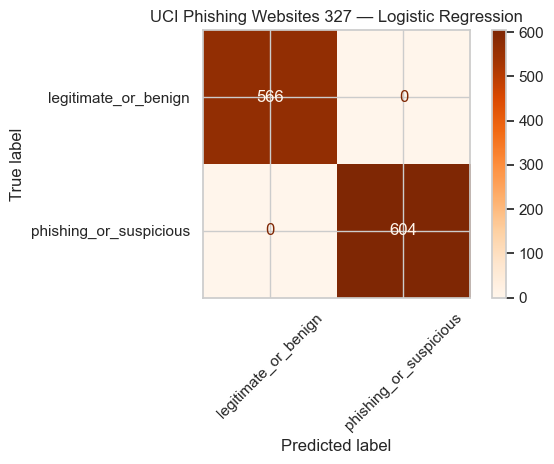


UCI PHISHING WEBSITES 327 — RANDOM FOREST
                        precision    recall  f1-score   support

  legitimate_or_benign       1.00      1.00      1.00       566
phishing_or_suspicious       1.00      1.00      1.00       604

              accuracy                           1.00      1170
             macro avg       1.00      1.00      1.00      1170
          weighted avg       1.00      1.00      1.00      1170



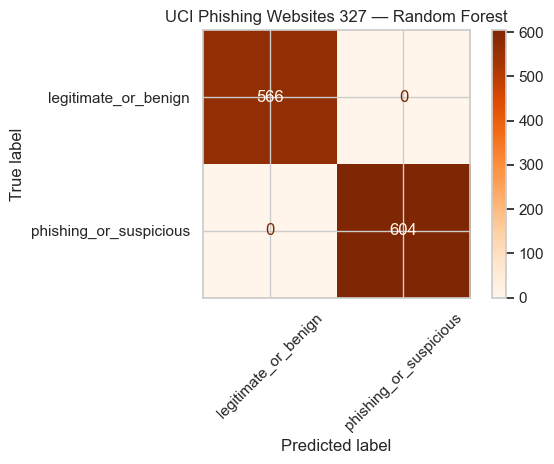

UCI Website Phishing 375 skipped: dataset unavailable.


In [37]:
# 7. Train the phishing website models

def build_tabular_preprocessor(X):
    numerical_columns = X.select_dtypes(
        include=np.number
    ).columns.tolist()

    categorical_columns = X.select_dtypes(
        exclude=np.number
    ).columns.tolist()

    numerical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler(with_mean=False)
        )
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ])

    transformers = []

    if numerical_columns:
        transformers.append(
            (
                "numerical",
                numerical_pipeline,
                numerical_columns
            )
        )

    if categorical_columns:
        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_columns
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

    return preprocessor


def remove_identifier_columns(X):
    X = X.copy()
    removed_columns = []

    for column in X.columns:
        normalized_name = str(column).strip().lower()

        unique_ratio = (
            X[column].nunique(dropna=False) / len(X)
            if len(X) > 0 else 0
        )

        obvious_id = normalized_name in {
            "id",
            "index",
            "row_id",
            "record_id",
            "unnamed_0"
        }

        identifier_name = (
            normalized_name.endswith("_id")
            and unique_ratio > 0.90
        )

        if obvious_id or identifier_name:
            removed_columns.append(column)

    if removed_columns:
        X = X.drop(columns=removed_columns)
        print("Identifier columns removed:", removed_columns)

    return X


tabular_results = []
tabular_models = {}


def train_tabular_models(dataset_name, dataframe, target_column):
    if dataframe is None:
        print(f"{dataset_name} skipped: dataset unavailable.")
        return

    if target_column is None:
        print(f"{dataset_name} skipped: target unavailable.")
        return

    working_data = dataframe.dropna(
        subset=[target_column]
    ).copy()

    X = working_data.drop(columns=[target_column])
    X = remove_identifier_columns(X)

    y = working_data[target_column].astype(str)

    if y.nunique() < 2:
        print(f"{dataset_name} has fewer than two classes.")
        return

    stratify_target = (
        y if y.value_counts().min() >= 2 else None
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=stratify_target
    )

    algorithms = {
        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    }

    for algorithm_name, classifier in algorithms.items():
        preprocessor = build_tabular_preprocessor(X)

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", classifier)
        ])

        pipeline.fit(X_train, y_train)

        predictions = pipeline.predict(X_test)

        result = {
            "Dataset": dataset_name,
            "Model": algorithm_name,
            "Accuracy": accuracy_score(
                y_test,
                predictions
            ),
            "Precision": precision_score(
                y_test,
                predictions,
                average="weighted",
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                predictions,
                average="weighted",
                zero_division=0
            ),
            "F1 Score": f1_score(
                y_test,
                predictions,
                average="weighted",
                zero_division=0
            )
        }

        tabular_results.append(result)

        model_key = f"{dataset_name} — {algorithm_name}"
        tabular_models[model_key] = pipeline

        print("\n" + "=" * 70)
        print(model_key.upper())
        print("=" * 70)

        print(
            classification_report(
                y_test,
                predictions,
                zero_division=0
            )
        )

        ConfusionMatrixDisplay.from_predictions(
            y_test,
            predictions,
            cmap="Oranges",
            xticks_rotation=45
        )

        plt.title(model_key)
        plt.tight_layout()
        plt.show()


train_tabular_models(
    "UCI Phishing Websites 327",
    primary_clean,
    target_columns.get("UCI Phishing Websites 327")
)

train_tabular_models(
    "UCI Website Phishing 375",
    backup_clean,
    target_columns.get("UCI Website Phishing 375")
)

In [38]:
#8. Compare every trained model

all_results = pd.DataFrame(
    email_results + tabular_results
)

if all_results.empty:
    raise ValueError(
        "No models were trained. Check the detected target columns."
    )

all_results = all_results.sort_values(
    by=["F1 Score", "Recall"],
    ascending=False
).reset_index(drop=True)

display(
    all_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Dataset,Model,Accuracy,Precision,Recall,F1 Score
0,Cyber Email Classification,Email Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,Cyber Email Classification,Email SGD Classifier,1.0000,1.0000,1.0000,1.0000
2,UCI Phishing Websites 327,Logistic Regression,1.0000,1.0000,1.0000,1.0000
3,UCI Phishing Websites 327,Random Forest,1.0000,1.0000,1.0000,1.0000


In [39]:
#9 Select and save the best models

best_email_model = None
best_phishing_model = None

# Select best email model
if email_results:
    email_results_df = pd.DataFrame(email_results)

    best_email_name = email_results_df.sort_values(
        ["F1 Score", "Recall"],
        ascending=False
    ).iloc[0]["Model"]

    best_email_model = email_models[best_email_name]

    email_model_path = (
        MODEL_DIR / "best_email_security_model.joblib"
    )

    joblib.dump(best_email_model, email_model_path)

    print("Best email model:", best_email_name)
    print("Saved to:", email_model_path)


# Select best phishing model
if tabular_results:
    tabular_results_df = pd.DataFrame(tabular_results)

    best_tabular_row = tabular_results_df.sort_values(
        ["F1 Score", "Recall"],
        ascending=False
    ).iloc[0]

    best_phishing_key = (
        f"{best_tabular_row['Dataset']} — "
        f"{best_tabular_row['Model']}"
    )

    best_phishing_model = tabular_models[
        best_phishing_key
    ]

    phishing_model_path = (
        MODEL_DIR / "best_phishing_website_model.joblib"
    )

    joblib.dump(
        best_phishing_model,
        phishing_model_path
    )

    print("\nBest phishing model:", best_phishing_key)
    print("Saved to:", phishing_model_path)

Best email model: Email Logistic Regression
Saved to: C:\Users\olayi\trained_models\best_email_security_model.joblib

Best phishing model: UCI Phishing Websites 327 — Logistic Regression
Saved to: C:\Users\olayi\trained_models\best_phishing_website_model.joblib


In [40]:
# Save Performance report

results_path = MODEL_DIR / "model_performance_results.csv"

all_results.to_csv(
    results_path,
    index=False
)

print("Performance results saved to:", results_path)

Performance results saved to: C:\Users\olayi\trained_models\model_performance_results.csv


In [41]:
#10. Test the saved email model

if best_email_model is not None:
    test_messages = [
        """
        Your account has been suspended. Click the link
        immediately and enter your password to restore access.
        """,

        """
        Hi Yisa, the project meeting has been moved to
        Thursday at 10 AM. Please confirm your availability.
        """
    ]

    test_predictions = best_email_model.predict(
        test_messages
    )

    test_results = pd.DataFrame({
        "Message": test_messages,
        "Predicted Class": test_predictions
    })

    display(test_results)

,Message,Predicted Class
0,\n Your account has been suspended. Cli...,phishing
1,"\n Hi Yisa, the project meeting has bee...",legitimate


In [43]:
#11. Reload the models later - for not need to be retraining the datasets every time:

email_model_file = (
    MODEL_DIR / "best_email_security_model.joblib"
)

phishing_model_file = (
    MODEL_DIR / "best_phishing_website_model.joblib"
)

if email_model_file.exists():
    loaded_email_model = joblib.load(
        email_model_file
    )

    print("Email model loaded successfully.")

if phishing_model_file.exists():
    loaded_phishing_model = joblib.load(
        phishing_model_file
    )

    print("Phishing model loaded successfully.")

Email model loaded successfully.
Phishing model loaded successfully.
